In [1]:
# All required libraries are installed in the virtual environment.
# No pip installation is required inside the notebook.

In [2]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Importing necessary libraries and modules

import warnings
warnings.filterwarnings("ignore")  # Ignore warnings during execution

import gc
import numpy as np
import pandas as pd
import itertools
from collections import Counter

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets

from torchvision.transforms import (
    Compose,
    Resize,
    RandomResizedCrop,
    RandomHorizontalFlip,
    RandomRotation,
    RandomAdjustSharpness,
    CenterCrop,
    Normalize,
    ToTensor
)

In [4]:
# Import the necessary module from the Python Imaging Library (PIL).
from PIL import ImageFile

# Allow PIL to load truncated/corrupted images instead of crashing.
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [5]:
# Import necessary libraries
from pathlib import Path
from tqdm import tqdm
import pandas as pd

# Initialize empty lists
file_names = []
labels = []

# Path to your dataset folder
dataset_path = Path("../dataset")

# Read all images from train and test folders
for file in sorted(dataset_path.glob("*/*/*")):
    if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        file_names.append(str(file))
        labels.append(file.parent.name)   # REAL or FAKE

# Create DataFrame
df = pd.DataFrame({
    "image": file_names,
    "label": labels
})

# Convert labels to numeric
label_map = {"REAL": 0, "FAKE": 1}
df["label_id"] = df["label"].map(label_map)

print("Total Images :", len(df))
print("Total Labels :", len(df["label"]))
print(df.shape)

df.head()

Total Images : 973
Total Labels : 973
(973, 3)


,image,label,label_id
0,..\dataset\test\FAKE\-how-important-people-fro...,FAKE,1
1,..\dataset\test\FAKE\082922_GeneratedArtAI_02_...,FAKE,1
2,..\dataset\test\FAKE\0EAwg7WIIMhgnSfLf.png,FAKE,1
3,..\dataset\test\FAKE\1000_F_555746402_GNMEIKpE...,FAKE,1
4,..\dataset\test\FAKE\1000_F_563719058_JXnzcPV4...,FAKE,1


In [6]:
import os

print(os.getcwd())

c:\Projects\deepfake_cnn\notebook


In [7]:
import os

print(os.listdir())

['best_model.pth', 'cnn_training.ipynb']


In [8]:
df['label'].unique()

array(['FAKE', 'REAL'], dtype=object)

In [9]:
# No Hugging Face Dataset is required.
# We'll use the Pandas DataFrame directly and create a custom PyTorch Dataset later.

dataset = df.copy()

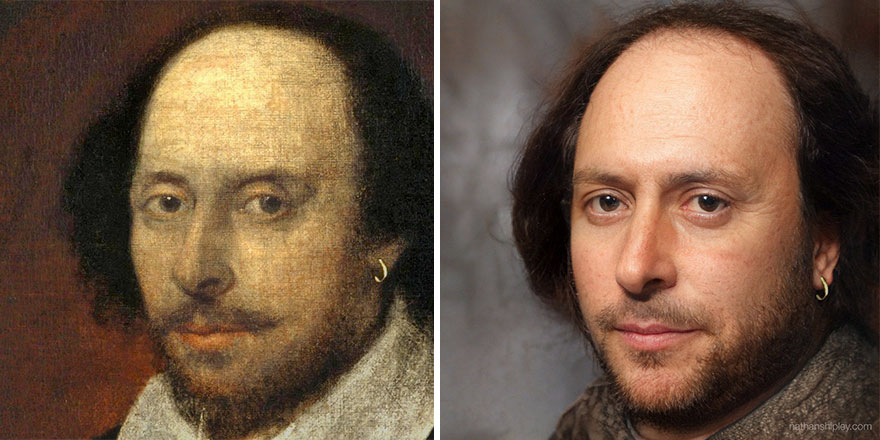

In [10]:
from PIL import Image

Image.open(dataset.iloc[0]["image"])

In [11]:
# Extracting a subset of elements from the 'labels' list using slicing.
# The slicing syntax [:5] selects the first 5 elements.

labels_subset = labels[:5]

# Printing the subset of labels to inspect the content.
print(labels_subset)

['FAKE', 'FAKE', 'FAKE', 'FAKE', 'FAKE']


In [12]:
# Create a list of unique labels
labels_list = ['REAL', 'FAKE']  # list(set(labels))

# Initialize dictionaries
label2id, id2label = dict(), dict()

# Create mappings
for i, label in enumerate(labels_list):
    label2id[label] = i
    id2label[i] = label

# Display the mappings
print("Mapping of IDs to Labels:", id2label, '\n')
print("Mapping of Labels to IDs:", label2id)

Mapping of IDs to Labels: {0: 'REAL', 1: 'FAKE'} 

Mapping of Labels to IDs: {'REAL': 0, 'FAKE': 1}


In [13]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets (60-40 split)
train_data, test_data = train_test_split(
    dataset,
    test_size=0.4,
    random_state=42,
    shuffle=True,
    stratify=dataset["label_id"]
)

# Reset indices
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

print("Training samples:", len(train_data))
print("Testing samples :", len(test_data))

Training samples: 583
Testing samples : 390


In [14]:
# Image size for CNN input
size = 224
print("Size:", size)

# ImageNet normalization (commonly used for pretrained CNNs)
image_mean = [0.485, 0.456, 0.406]
image_std = [0.229, 0.224, 0.225]

# Define normalization
normalize = Normalize(mean=image_mean, std=image_std)

# Training transformations
from torchvision.transforms import (
    Compose,
    RandomResizedCrop,
    RandomHorizontalFlip,
    RandomRotation,
    ColorJitter,
    ToTensor,
    Normalize
)

_train_transforms = Compose([
    RandomResizedCrop(224, scale=(0.8, 1.0)),
    RandomHorizontalFlip(),
    RandomRotation(15),

    ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    ToTensor(),
    normalize
])
# Validation transformations
_val_transforms = Compose([
    Resize((size, size)),
    ToTensor(),
    normalize
])

# Transformation function for training images
def train_transforms(image):
    return _train_transforms(image.convert("RGB"))

# Transformation function for validation images
def val_transforms(image):
    return _val_transforms(image.convert("RGB"))

Size: 224


In [15]:
# No action required here.
# The training and validation transforms will be passed to the
# custom PyTorch Dataset when we create it.

train_transform = train_transforms
val_transform = val_transforms

In [16]:
# No custom collate function is required for the CNN implementation.
# The PyTorch DataLoader will automatically stack images and labels
# returned by the custom Dataset class.

Load, train and evaluate model

In [17]:
from torchvision.models import resnet18

# Load a pretrained ResNet18 model
model = resnet18(weights="DEFAULT")

for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# Replace the final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(labels_list))

# Store label mappings (optional, similar to ViT)
model.id2label = id2label
model.label2id = label2id

# Calculate and print the number of trainable parameters (in millions)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params / 1e6)

10.494466


In [18]:
from sklearn.metrics import accuracy_score

# Function to compute accuracy
def compute_metrics(labels, predictions):
    acc_score = accuracy_score(labels, predictions)

    return {
        "accuracy": acc_score
    }

In [19]:
# Evaluation metric
metric_name = "accuracy"

# Model name (used for saving the trained model)
model_name = "ai_vs_real_image_detection"

# Training hyperparameters
num_train_epochs = 30
learning_rate = 1e-4
train_batch_size = 64
eval_batch_size = 32
weight_decay = 0.02

In [20]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# Custom Dataset class
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx]["image"]
        label = self.dataframe.iloc[idx]["label_id"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# Create datasets
train_dataset = ImageDataset(train_data, transform=train_transform)
test_dataset = ImageDataset(test_data, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=eval_batch_size,
    shuffle=False
)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=0.01
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

In [21]:
best_acc = 0.0

for epoch in range(num_train_epochs):

    # -------------------- Training --------------------
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------------------- Validation --------------------
    model.eval()

    val_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(test_loader)

    val_accuracy = accuracy_score(all_labels, all_preds)

    scheduler.step(val_accuracy)

    if val_accuracy > best_acc:
        best_acc = val_accuracy
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1}/{num_train_epochs}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_accuracy:.4f}")
    print("-"*40)

Epoch 1/30
Train Loss : 0.6033
Val Loss   : 1.1462
Val Acc    : 0.6103
----------------------------------------
Epoch 2/30
Train Loss : 0.3592
Val Loss   : 0.6267
Val Acc    : 0.7846
----------------------------------------
Epoch 3/30
Train Loss : 0.2344
Val Loss   : 0.4799
Val Acc    : 0.8051
----------------------------------------
Epoch 4/30
Train Loss : 0.2002
Val Loss   : 0.5076
Val Acc    : 0.8051
----------------------------------------
Epoch 5/30
Train Loss : 0.1271
Val Loss   : 0.5078
Val Acc    : 0.8205
----------------------------------------
Epoch 6/30
Train Loss : 0.1203
Val Loss   : 0.5110
Val Acc    : 0.8231
----------------------------------------
Epoch 7/30
Train Loss : 0.0764
Val Loss   : 0.5224
Val Acc    : 0.8333
----------------------------------------
Epoch 8/30
Train Loss : 0.0648
Val Loss   : 0.5776
Val Acc    : 0.8179
----------------------------------------
Epoch 9/30
Train Loss : 0.0819
Val Loss   : 0.5489
Val Acc    : 0.8051
---------------------------------

In [22]:
import torch
import torchvision

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

PyTorch Version: 2.13.0+cpu
Torchvision Version: 0.28.0+cpu


In [23]:
# Evaluate the model on the test dataset
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []
running_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute metrics
metrics = compute_metrics(all_labels, all_preds)

print(f"Validation Loss: {running_loss / len(test_loader):.4f}")
print(f"Validation Accuracy: {metrics['accuracy']:.4f}")

Validation Loss: 0.6040
Validation Accuracy: 0.8410


In [24]:
print(df["label"].value_counts())

label
FAKE    539
REAL    434
Name: count, dtype: int64


In [25]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
print(cm)

              precision    recall  f1-score   support

           0       0.84      0.79      0.82       174
           1       0.84      0.88      0.86       216

    accuracy                           0.84       390
   macro avg       0.84      0.84      0.84       390
weighted avg       0.84      0.84      0.84       390

[[138  36]
 [ 26 190]]
